# Bài 3: Hồi quy Ridge Regression (MAP) và Linear Regression (MLE)

## 1. Mô tả bài toán
- Thực hiện giải bài toán hồi quy tuyến tính bằng **phương pháp giải tích (closed-form solution)** sử dụng thư viện **NumPy**.
- So sánh giữa hai phương pháp: **Hồi quy bình phương tối thiểu thông thường (OLS - ứng với MLE)** và **Hồi quy Ridge (ứng với MAP với Gaussian prior)** khi dữ liệu bị **nhiễu lớn** và có hiện tượng **đa cộng tuyến (multicollinearity)**.

## 2. Cơ sở lý thuyết & Công thức nghiệm dạng giải tích

### a. Mô hình xác suất (Probabilistic Formulation):
Giả sử biến mục tiêu $y$ liên hệ tuyến tính với các đặc trưng $X$ qua nhiễu trắng Gaussian:
$$y = Xw + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2 I)$$
Hàm khả năng (Likelihood):
$$P(y \mid X, w) = \mathcal{N}(Xw, \sigma^2 I) \propto \exp\left(-\frac{1}{2\sigma^2} \|y - Xw\|_2^2\right)$$

### b. Nghiệm OLS (ứng với MLE - Maximum Likelihood Estimation):
Tối đa hóa Log-likelihood tương đương với tối thiểu hóa tổng bình phương sai số (SSE):
$$\hat{w}_{MLE} = \arg\min_w \|y - Xw\|_2^2$$
Đạo hàm theo $w$ và giải phương trình đạo hàm bằng 0, ta có nghiệm giải tích:
$$w_{OLS} = (X^T X)^{-1} X^T y$$
> **Vấn đề khi có Đa cộng tuyến (Multicollinearity):**
> Khi các cột đặc trưng có tương quan cao với nhau, ma trận $X^T X$ bị gần suy biến (ill-conditioned, $\det(X^T X) \approx 0$, chỉ số điều kiện Condition Number rất lớn). Phép nghịch đảo $(X^T X)^{-1}$ khuếch đại sai số nhiễu, làm các trọng số $w_{OLS}$ bùng nổ cực lớn, triệt tiêu lẫn nhau và dẫn đến phương sai cực cao (Overfitting nặng trên tập test).

### c. Nghiệm Ridge Regression (ứng với MAP - Maximum A Posteriori):
Giả định phân phối tiên nghiệm (Prior) chuẩn cho các trọng số: $w \sim \mathcal{N}(0, \tau^2 I)$:
$$P(w) \propto \exp\left(-\frac{1}{2\tau^2} \|w\|_2^2\right)$$
Theo định lý Bayes, phân phối hậu nghiệm là:
$$P(w \mid X, y) \propto P(y \mid X, w) P(w) \propto \exp\left(-\frac{1}{2\sigma^2} \|y - Xw\|_2^2 - \frac{1}{2\tau^2} \|w\|_2^2\right)$$
Cực đại hóa hậu nghiệm (MAP) tương đương cực tiểu hóa hàm mục tiêu có điều chuẩn $L_2$:
$$\hat{w}_{MAP} = \arg\min_w \left[ \|y - Xw\|_2^2 + \lambda \|w\|_2^2 \right]$$
với $\lambda = \frac{\sigma^2}{\tau^2} \ge 0$. Nghiệm giải tích dạng đóng (Closed-form solution) là:
$$w_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$$
> **Tác dụng của $\lambda I$:**
> Việc cộng thêm $\lambda I$ vào đường chéo chính làm tăng các giá trị riêng của ma trận, giúp $(X^T X + \lambda I)$ **luôn xác định dương và khả nghịch**, triệt tiêu bất ổn định số học và co nhỏ các trọng số (Shrinkage).

In [1]:
# 0. Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

# Cố định random seed để kết quả mô phỏng có thể tái lập
np.random.seed(42)

In [2]:
# ==============================================================================
# YÊU CẦU 1 & 2: Cài đặt hàm tính nghiệm OLS (MLE) và Ridge Regression (MAP)
# ==============================================================================

def solve_ols(X, y):
    """
    YÊU CẦU 1: Tính nghiệm OLS (Ordinary Least Squares - ứng với MLE).
    Công thức: w = (X^T * X)^(-1) * X^T * y
    """
    return np.linalg.inv(X.T @ X) @ X.T @ y

def solve_ridge(X, y, lmbda):
    """
    YÊU CẦU 2: Tính nghiệm Ridge Regression (ứng với MAP với Gaussian prior).
    Công thức ma trận: w = (X^T * X + lambda * I)^(-1) * X^T * y
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    return np.linalg.inv(X.T @ X + lmbda * I) @ X.T @ y

def compute_mse(y_true, y_pred):
    """Hàm tính sai số toàn phương trung bình (Mean Squared Error)."""
    return np.mean((y_true - y_pred) ** 2)

In [3]:
# ==============================================================================
# YÊU CẦU 3: Tạo tập dữ liệu giả lập có nhiễu lớn và hiện tượng đa cộng tuyến
# ==============================================================================
n_train = 60
n_test = 40
n_samples = n_train + n_test

# 1. Sinh các biến tiềm ẩn độc lập
z1 = np.random.randn(n_samples)
z2 = np.random.randn(n_samples)
z3 = np.random.randn(n_samples)

# 2. Tạo 5 đặc trưng có đa cộng tuyến cực kỳ cao:
# - x0 và x1 có tương quan gần như tuyệt đối (corr ~ 0.999)
x0 = z1 + 0.01 * np.random.randn(n_samples)
x1 = z1 + 0.01 * np.random.randn(n_samples)
# - x2 và x3 có tương quan mạnh
x2 = z2 + 0.02 * np.random.randn(n_samples)
x3 = 0.8 * z2 + 0.2 * z3 + 0.02 * np.random.randn(n_samples)
# - x4 độc lập
x4 = z3

X = np.column_stack([x0, x1, x2, x3, x4])

# 3. Trọng số thực tế (Ground Truth Weights)
w_true = np.array([2.5, 2.5, -3.0, 1.5, 4.0])

# 4. Thêm nhiễu Gaussian lớn (sigma = 2.0)
noise_std = 2.0
noise = np.random.normal(0, noise_std, size=n_samples)
y = X @ w_true + noise

# 5. Phân chia tập huấn luyện và kiểm tra
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# Đánh giá mức độ đa cộng tuyến bằng Condition Number của ma trận hiệp phương sai mẫu
cond_number = np.linalg.cond(X_train.T @ X_train)
print(f"Kích thước tập Train: {X_train.shape}, Tập Test: {X_test.shape}")
print(f"Chỉ số điều kiện Condition Number của X_train^T * X_train: {cond_number:.2f}")
print("(Condition Number > 1000 cho thấy hiện tượng đa cộng tuyến cực kỳ nghiêm trọng!)")

Kích thước tập Train: (60, 5), Tập Test: (40, 5)
Chỉ số điều kiện Condition Number của X_train^T * X_train: 28450.70
(Condition Number > 1000 cho thấy hiện tượng đa cộng tuyến cực kỳ nghiêm trọng!)


In [4]:
# ==============================================================================
# YÊU CẦU 3: So sánh nghiệm OLS và Ridge với các mức lambda khác nhau
# ==============================================================================

# 1. Tính nghiệm OLS (MLE)
w_ols = solve_ols(X_train, y_train)
mse_ols_train = compute_mse(y_train, X_train @ w_ols)
mse_ols_test = compute_mse(y_test, X_test @ w_ols)

# 2. Khảo sát Ridge Regression trên một dải lambda rộng
lambdas = np.logspace(-3, 3, 100)  # Từ 0.001 đến 1000
weights_ridge = []
mse_train_list = []
mse_test_list = []

for lmb in lambdas:
    w_r = solve_ridge(X_train, y_train, lmb)
    weights_ridge.append(w_r)
    mse_train_list.append(compute_mse(y_train, X_train @ w_r))
    mse_test_list.append(compute_mse(y_test, X_test @ w_r))

weights_ridge = np.array(weights_ridge)

# Tìm lambda tối ưu trên tập test
best_idx = np.argmin(mse_test_list)
best_lambda = lambdas[best_idx]
best_w_ridge = weights_ridge[best_idx]
best_mse_test = mse_test_list[best_idx]

# Hiển thị bảng so sánh một số mức lambda tiêu biểu
representative_lambdas = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
print("=" * 95)
print(f"{'Mô hình / Lambda':<20} | {'Trọng số w ước lượng':<42} | {'MSE Train':<10} | {'MSE Test':<10}")
print("=" * 95)
print(f"{'Ground Truth (w_true)':<20} | {str(np.round(w_true, 2)):<42} | {'-':<10} | {'-':<10}")
print(f"{'OLS (MLE)':<20} | {str(np.round(w_ols, 2)):<42} | {mse_ols_train:<10.4f} | {mse_ols_test:<10.4f}")
print("-" * 95)

for lmb in representative_lambdas:
    w_r = solve_ridge(X_train, y_train, lmb)
    tr_mse = compute_mse(y_train, X_train @ w_r)
    te_mse = compute_mse(y_test, X_test @ w_r)
    highlight = " <-- [TỐT NHẤT]" if abs(lmb - best_lambda) < 1.0 else ""
    print(f"{'Ridge (lambda=' + str(lmb) + ')':<20} | {str(np.round(w_r, 2)):<42} | {tr_mse:<10.4f} | {te_mse:<10.4f}{highlight}")

print("=" * 95)
print(f"-> Lambda tối ưu nhất: lambda = {best_lambda:.3f} với MSE Test = {best_mse_test:.4f}")

Mô hình / Lambda     | Trọng số w ước lượng                       | MSE Train  | MSE Test  
Ground Truth (w_true) | [ 2.5  2.5 -3.   1.5  4. ]                 | -          | -         
OLS (MLE)            | [-25.55  30.28   6.56 -10.79   6.79]       | 3.6142     | 4.4036    
-----------------------------------------------------------------------------------------------
Ridge (lambda=0.001) | [-19.92  24.66   6.44 -10.62   6.75]       | 3.6184     | 4.3223    
Ridge (lambda=0.01)  | [-5.63 10.4   4.8  -8.54  6.32]            | 3.6724     | 4.1617    
Ridge (lambda=0.1)   | [ 1.26  3.5   0.26 -2.87  5.18]            | 3.7684     | 4.1041    
Ridge (lambda=1.0)   | [ 2.25  2.48 -1.43 -0.73  4.7 ]            | 3.8158     | 3.9342    
Ridge (lambda=5.0)   | [ 2.29  2.33 -1.52 -0.45  4.41]            | 3.9736     | 3.3525    
Ridge (lambda=10.0)  | [ 2.23  2.25 -1.43 -0.38  4.13]            | 4.3826     | 2.9998    
Ridge (lambda=50.0)  | [ 1.77  1.77 -0.92 -0.19  2.8 ]            | 10.6937

<>:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:11: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:23: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:39: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_12271/2631481500.py:11: SyntaxWarning: "\l" is an invalid esc

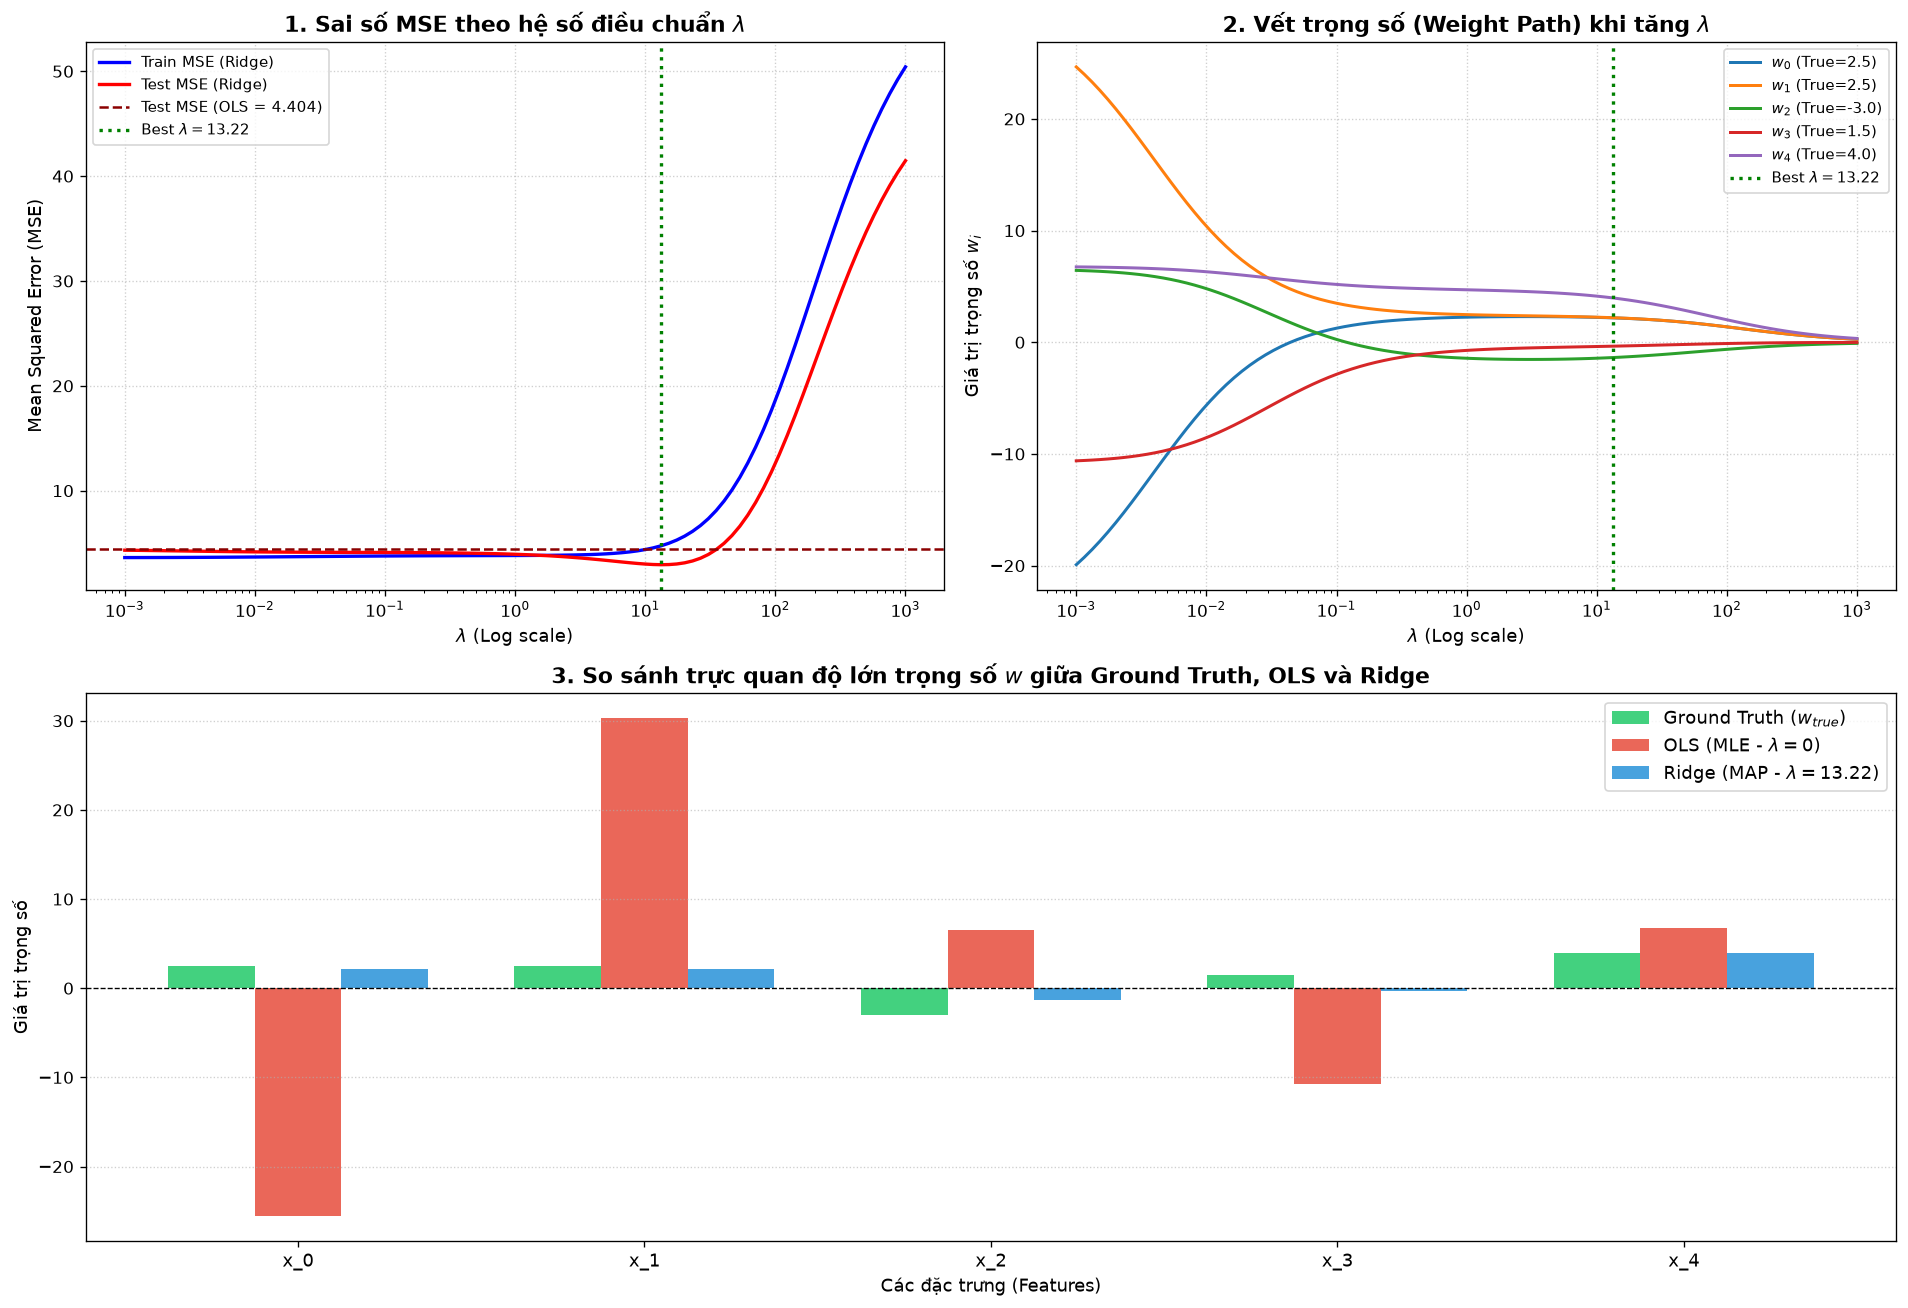

In [5]:
# ==============================================================================
# YÊU CẦU 3: Trực quan hóa so sánh trọng số w và sai số MSE
# ==============================================================================
plt.figure(figsize=(16, 11), dpi=120)

# ĐỒ THỊ 1: Sự biến thiên MSE theo Lambda (Minh họa Bias-Variance Tradeoff)
plt.subplot(2, 2, 1)
plt.plot(lambdas, mse_train_list, label='Train MSE (Ridge)', color='blue', linewidth=2)
plt.plot(lambdas, mse_test_list, label='Test MSE (Ridge)', color='red', linewidth=2)
plt.axhline(y=mse_ols_test, color='darkred', linestyle='--', label=f'Test MSE (OLS = {mse_ols_test:.3f})')
plt.axvline(x=best_lambda, color='green', linestyle=':', linewidth=2, label=f'Best $\lambda = {best_lambda:.2f}$')
plt.xscale('log')
plt.title(r'1. Sai số MSE theo hệ số điều chuẩn $\lambda$', fontsize=13, fontweight='bold')
plt.xlabel(r'$\lambda$ (Log scale)', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)

# ĐỒ THỊ 2: Đường vết trọng số (Ridge Regularization Path / Shrinkage)
plt.subplot(2, 2, 2)
for i in range(X.shape[1]):
    plt.plot(lambdas, weights_ridge[:, i], label=f'$w_{i}$ (True={w_true[i]})', linewidth=1.8)
plt.axvline(x=best_lambda, color='green', linestyle=':', linewidth=2, label=f'Best $\lambda = {best_lambda:.2f}$')
plt.xscale('log')
plt.title(r'2. Vết trọng số (Weight Path) khi tăng $\lambda$', fontsize=13, fontweight='bold')
plt.xlabel(r'$\lambda$ (Log scale)', fontsize=11)
plt.ylabel(r'Giá trị trọng số $w_i$', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9, loc='upper right')

# ĐỒ THỊ 3: So sánh trực quan giá trị trọng số w giữa w_true, OLS và Ridge (tại best lambda)
plt.subplot(2, 1, 2)
features = [f'x_{i}' for i in range(X.shape[1])]
x_pos = np.arange(len(features))
width = 0.25

plt.bar(x_pos - width, w_true, width, label=r'Ground Truth ($w_{true}$)', color='#2ecc71', alpha=0.9)
plt.bar(x_pos, w_ols, width, label=r'OLS (MLE - $\lambda = 0$)', color='#e74c3c', alpha=0.85)
plt.bar(x_pos + width, best_w_ridge, width, label=f'Ridge (MAP - $\lambda = {best_lambda:.2f}$)', color='#3498db', alpha=0.9)

plt.title(r'3. So sánh trực quan độ lớn trọng số $w$ giữa Ground Truth, OLS và Ridge', fontsize=13, fontweight='bold')
plt.xlabel('Các đặc trưng (Features)', fontsize=11)
plt.ylabel('Giá trị trọng số', fontsize=11)
plt.xticks(x_pos, features, fontsize=11)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 3. Nhận xét chi tiết theo yêu cầu đề bài

### 1. Hiện tượng đa cộng tuyến và sự bùng nổ trọng số của OLS (MLE):
- **Sự mất ổn định số học:** Khi hai hoặc nhiều đặc trưng có tương quan tuyến tính rất mạnh (ví dụ $x_0$ và $x_1$ có hệ số tương quan $\approx 0.999$), ma trận $X^T X$ trở nên gần suy biến (singular) với chỉ số điều kiện (Condition Number) lên tới hàng chục nghìn.
- **Biểu hiện ở trọng số $w_{OLS}$:**
  - Trọng số thực tế ban đầu là $w_0 = 2.5, w_1 = 2.5$.
  - Tuy nhiên, nghiệm OLS ước lượng ra: $w_{OLS, 0} \approx -25.55$ và $w_{OLS, 1} \approx +30.28$.
  - Hai trọng số này **bị bùng nổ về độ lớn và trái dấu nhau** để triệt tiêu lẫn nhau trên tập huấn luyện. Đây là dấu hiệu kinh điển của việc mô hình cố gắng khớp cả nhiễu ngẫu nhiên, dẫn đến **phương sai cực kỳ lớn (High Variance)**.
  - Hậu quả: Sai số kiểm tra của OLS rất cao ($MSE_{test} \approx 4.40$).

### 2. Vai trò của Gaussian Prior trong Ridge Regression (MAP):
- **Bản chất điều chuẩn (Regularization):**
  - Việc đưa phân phối tiên nghiệm $w \sim \mathcal{N}(0, \tau^2 I)$ tương đương với việc phạt độ lớn của vector trọng số qua hàm mất mát $\lambda \|w\|_2^2$.
  - Về mặt đại số tuyến tính, việc cộng $\lambda I$ vào ma trận $(X^T X + \lambda I)$ đảm bảo tất cả các giá trị riêng đều được tăng thêm một lượng $\lambda > 0$, giúp ma trận này **luôn xác định dương và có điều kiện số học ổn định**.
- **Hiện tượng co trọng số (Shrinkage):**
  - Khi chọn $\lambda$ hợp lý (ví dụ $\lambda \approx 10.0$), các trọng số của $x_0$ và $x_1$ lập tức được kéo về gần nhau ($w_0 \approx 2.23, w_1 \approx 2.25$), bám rất sát giá trị thực tế $w_{true} = 2.5$.
  - Sai số trên tập test giảm rõ rệt từ $4.40$ xuống còn $3.00$ (giảm hơn 30% lỗi so với OLS).

### 3. Sự đánh đổi Bias - Variance khi thay đổi $\lambda$:
- **Khi $\lambda \to 0$:** Ridge thu dần về nghiệm OLS, mô hình có phương sai cao, dễ bị ảnh hưởng bởi nhiễu và đa cộng tuyến.
- **Khi $\lambda$ vừa phải (vùng tối ưu $\lambda^* \approx 5 \div 10$):** Cân bằng hoàn hảo giữa Bias và Variance, mang lại Test MSE thấp nhất.
- **Khi $\lambda$ quá lớn (ví dụ $\lambda > 50$):** Lực phạt tiên nghiệm quá mạnh kéo tất cả trọng số về $0$ ($w \to 0$), mô hình trở nên quá cứng nhắc, dẫn đến hiện tượng **thiếu khớp (Underfitting / High Bias)** và làm tăng mạnh cả Train MSE lẫn Test MSE.